In [1]:
import sys
print(sys.executable)

c:\Users\Alvin\anaconda3\python.exe


In [2]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


TensorFlow version: 2.20.0
Num GPUs Available: 0


In [3]:
# Then import the required libraries
import importlib
import numpy as np
import os
import random

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
# Remove standalone keras imports and use tf.keras instead
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
# Update keras imports to use tf.keras
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
# Use tf.keras.models instead
from sklearn.model_selection import GridSearchCV
import joblib

In [4]:
#all genes

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV
from imblearn.under_sampling import RandomUnderSampler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization, ReLU, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import time

# -------------------------------
# CONFIGURATION
# -------------------------------
seed = 0
np.random.seed(seed)

# Load data
X_train = pd.read_csv("../../Datasets/X_train_Norway_purified.csv")
X_test = pd.read_csv("../../Datasets/X_test_Norway_purified.csv")
y_train = pd.read_csv("../../Datasets/y_train_Norway_purified.csv").values.ravel()
y_test = pd.read_csv("../../Datasets/y_test_Norway_purified.csv").values.ravel()


# Label encode
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
n_classes = len(le.classes_)

# IRUS
sm = RandomUnderSampler(random_state=seed)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train_enc)

# One-hot encode labels
y_train_oh = to_categorical(y_train_sm, num_classes=n_classes)
y_test_oh = to_categorical(y_test_enc, num_classes=n_classes)

input_dim = X_train_sm.shape[1]

# -------------------------------
# AUTOENCODER
# -------------------------------
def build_autoencoder(input_dim, encoding_dim=500, hidden_dim1=5000, hidden_dim2=2000, 
                      l2_reg=1e-14, learning_rate=3e-5):
    """Build encoder + autoencoder"""
    inp = Input(shape=(input_dim,))
    x = Dense(hidden_dim1, kernel_regularizer=regularizers.l2(l2_reg))(inp)
    x = LeakyReLU()(x)
    x = Dense(hidden_dim2, kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = LeakyReLU()(x)
    encoded = Dense(encoding_dim, kernel_regularizer=regularizers.l2(l2_reg))(x)
    encoded = ReLU()(encoded)
    
    # Decoder
    x = Dense(hidden_dim2, kernel_regularizer=regularizers.l2(l2_reg))(encoded)
    x = LeakyReLU()(x)
    x = Dense(hidden_dim1, kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = LeakyReLU()(x)
    decoded = Dense(input_dim, activation='linear')(x)
    
    autoencoder = Model(inputs=inp, outputs=decoded)
    autoencoder.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['accuracy'])
    
    encoder = Model(inputs=inp, outputs=encoded)
    return autoencoder, encoder

autoencoder, encoder = build_autoencoder(input_dim)
autoencoder.fit(X_train_sm, X_train_sm, epochs=100, batch_size=32, verbose=1, shuffle=True)

# Encode features
X_train_encoded = encoder.predict(X_train_sm)
X_test_encoded = encoder.predict(X_test)



Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.0000e+00 - loss: 0.2602
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.0000e+00 - loss: 0.2350
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.0000e+00 - loss: 0.1709
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.0000e+00 - loss: 0.0986
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.0000e+00 - loss: 0.0467
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.0143 - loss: 0.0229  
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.0571 - loss: 0.0155  
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.0143 - loss: 0.0130
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.0000e+00 - loss: 0.0110
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.0000e+00 - loss: 0.0093
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.0000e+00 - loss: 0.0080
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy:

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END batch_size=16, model__activation=tanh, model__dropout_rate1=0.1, model__dropout_rate2=0.3, model__hidden_dim=200, model__learning_rate=0.0001;, score=(train=0.427, test=0.190) total time=   4.1s
[CV 2/5] END batch_size=16, model__activation=tanh, model__dropout_rate1=0.1, model__dropout_rate2=0.3, model__hidden_dim=200, model__learning_rate=0.0001;, score=(train=0.635, test=0.371) total time=   4.5s
[CV 3/5] END batch_size=16, model__activation=tanh, model__dropout_rate1=0.1, model__dropout_rate2=0.3, model__hidden_dim=200, model__learning_rate=0.0001;, score=(train=0.455, test=0.327) total time=   3.3s
[CV 4/5] END batch_size=16, model__activation=tanh, model__dropout_rate1=0.1, model__dropout_rate2=0.3, model__hidden_dim=200, model__learning_rate=0.0001;, score=(train=0.662, test=0.490) total time=   4.7s
[CV 5/5] END batch_size=16, model__activation=tanh, model__dropout_rate1=0.1, model__dropout_rate2=0.3, mo

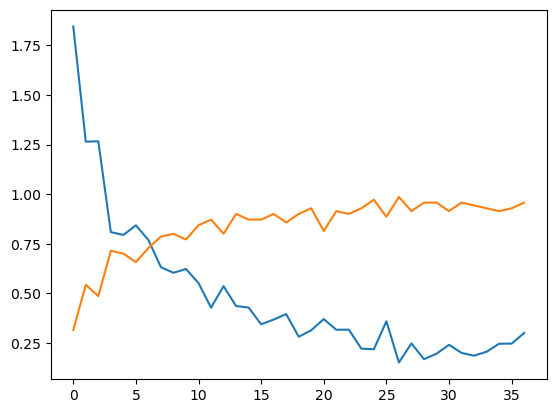


Classification Report:
              precision    recall  f1-score   support

       Basal       1.00      0.14      0.25         7
        Her2       0.00      0.00      0.00         7
        LumA       0.45      1.00      0.62        24
        LumB       0.00      0.00      0.00        12
      Normal       0.00      0.00      0.00         4

    accuracy                           0.46        54
   macro avg       0.29      0.23      0.17        54
weighted avg       0.33      0.46      0.31        54



c:\Users\Alvin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Alvin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Alvin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


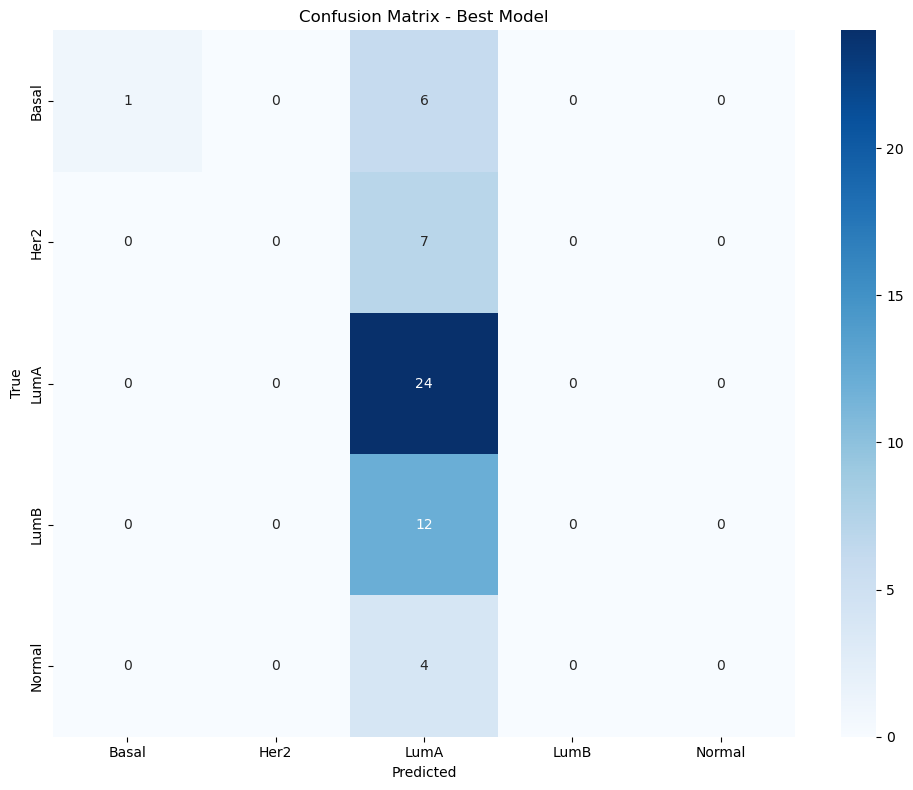


TOP 10 CONFIGURATIONS:

Rank 1:
  Score: 0.3912 (+/- 0.1060)
  Parameters: {'model__learning_rate': 0.002, 'model__hidden_dim': 200, 'model__dropout_rate2': 0.2, 'model__dropout_rate1': 0.3, 'model__activation': 'leakyrelu', 'batch_size': 16}

Rank 2:
  Score: 0.3658 (+/- 0.0981)
  Parameters: {'model__learning_rate': 0.001, 'model__hidden_dim': 200, 'model__dropout_rate2': 0.4, 'model__dropout_rate1': 0.1, 'model__activation': 'leakyrelu', 'batch_size': 16}

Rank 3:
  Score: 0.3167 (+/- 0.0356)
  Parameters: {'model__learning_rate': 0.001, 'model__hidden_dim': 200, 'model__dropout_rate2': 0.1, 'model__dropout_rate1': 0.2, 'model__activation': 'leakyrelu', 'batch_size': 16}

Rank 4:
  Score: 0.2908 (+/- 0.1440)
  Parameters: {'model__learning_rate': 0.0001, 'model__hidden_dim': 200, 'model__dropout_rate2': 0.3, 'model__dropout_rate1': 0.1, 'model__activation': 'tanh', 'batch_size': 16}

Rank 5:
  Score: 0.2902 (+/- 0.1310)
  Parameters: {'model__learning_rate': 0.002, 'model__hidden_d

In [6]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score, make_scorer
from sklearn.model_selection import StratifiedKFold
import joblib

class HistoryLogger(tf.keras.callbacks.Callback):
    def on_train_end(self, logs=None):
        # This will stay attached to the model after RandomizedSearchCV finishes
        self.model.final_history = self.model.history.history
# -------------------------------
# CLASSIFIER
# -------------------------------
def create_classifier(hidden_dim=200, dropout_rate1=0.2, dropout_rate2=0.3, 
                      learning_rate=2e-5, activation='relu'):
    inp = Input(shape=(X_train_encoded.shape[1],))
    x = BatchNormalization()(inp)
    x = Dropout(dropout_rate1, seed=seed)(x)

   
    # Activation
    if activation == 'leakyrelu':
        x = Dense(hidden_dim)(x)
        x = LeakyReLU(negative_slope=0.01)(x)
    elif activation == 'relu':
        x = Dense(hidden_dim)(x)
        x = ReLU()(x)
    else:
        x = Dense(hidden_dim, activation='tanh')(x)

    x = BatchNormalization()(x)
    x = Dropout(dropout_rate2, seed=seed)(x)
    out = Dense(n_classes, activation='softmax')(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Wrap with scikeras KerasClassifier
clf = KerasClassifier(
    model=create_classifier,
    epochs=100, 
    verbose=0,
    loss='sparse_categorical_crossentropy',
    random_state=seed,
    callbacks=[EarlyStopping(monitor='loss', patience=10, restore_best_weights=True), HistoryLogger()]

)

# -------------------------------
# RANDOMIZED SEARCH
# -------------------------------
param_dist = {
    'model__hidden_dim': [200],
    'model__dropout_rate1': [0.1, 0.2, 0.3],
    'model__dropout_rate2': [0.1, 0.2, 0.3, 0.4, 0.5],
    'model__learning_rate': [0.01, 0.002, 0.001, 0.0001],
    'model__activation': ['relu', 'tanh', 'leakyrelu'],
    'batch_size': [16, 32, 64]
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)


random_search = RandomizedSearchCV(
    clf,
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1_weighted',
    cv=cv_strat,
    n_jobs=1,  
    random_state=seed,
    return_train_score=True,
    verbose=3
)

# Fit model
start = time.time()
random_search.fit(X_train_encoded, y_train_sm)
end = time.time()
print(f"RandomizedSearchCV completed in {(end-start)/60:.2f} minutes")

# -------------------------------
# EVALUATION
# -------------------------------
# Test on held-out test set
test_acc = random_search.score(X_test_encoded, y_test_enc)
print(f"Test set Score: {test_acc:.4f}")

best_model = random_search.best_estimator_
final_history = best_model.model_.final_history


joblib.dump(best_model, "NN_Norway_IRUS_RS_AE_Purified_bestmodel.pkl")
print("Best estimator saved to 'NN_Norway_IRUS_RS_AE_Purified_bestmodel.pkl'")

plt.plot(final_history['loss'], label='Loss')
plt.plot(final_history['accuracy'], label='Accuracy')
plt.show()

# Predict class labels
y_pred_classes = best_model.predict(X_test_encoded)

print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_classes, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test_enc, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Best Model')
plt.tight_layout()
plt.show()

# Create results dataframe
results_df = pd.DataFrame(random_search.cv_results_)
results_df = results_df.sort_values('rank_test_score')

# Show top 10 configurations
print("\n" + "="*80)
print("TOP 10 CONFIGURATIONS:")
print("="*80)
top_10 = results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].head(10)
for idx, row in top_10.iterrows():
    print(f"\nRank {int(row['rank_test_score'])}:")
    print(f"  Score: {row['mean_test_score']:.4f} (+/- {row['std_test_score']:.4f})")
    print(f"  Parameters: {row['params']}")


Test Score (Best Neural Network): 0.3095

Classification Report:
              precision    recall  f1-score   support

       Basal       1.00      0.14      0.25         7
        Her2       0.00      0.00      0.00         7
        LumA       0.45      1.00      0.62        24
        LumB       0.00      0.00      0.00        12
      Normal       0.00      0.00      0.00         4

    accuracy                           0.46        54
   macro avg       0.29      0.23      0.17        54
weighted avg       0.33      0.46      0.31        54



c:\Users\Alvin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Alvin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Alvin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


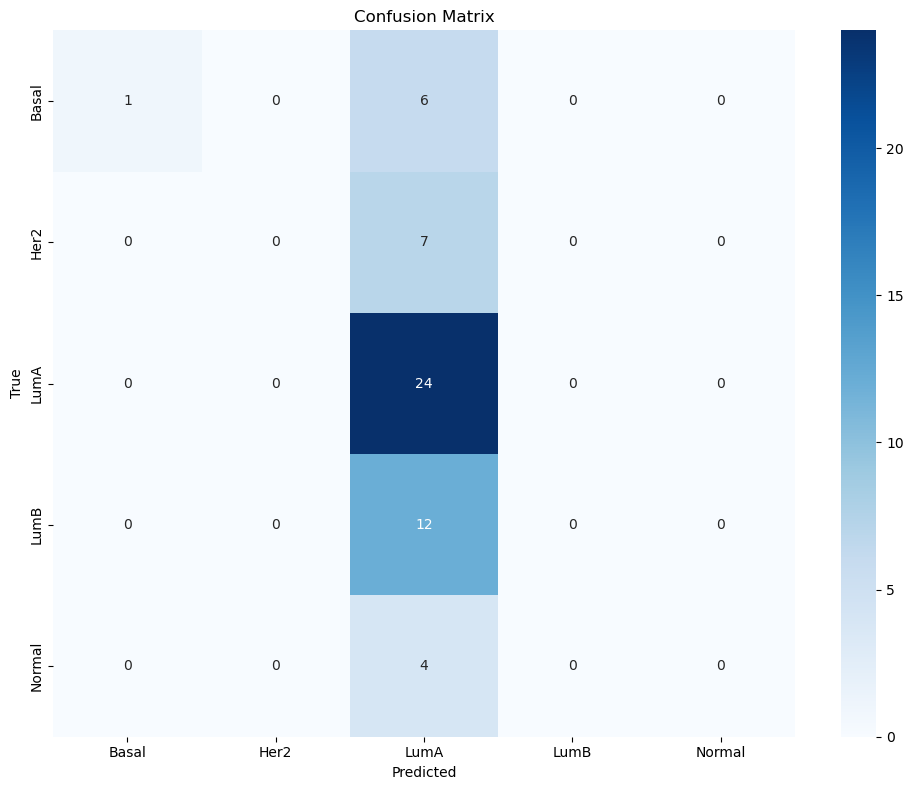

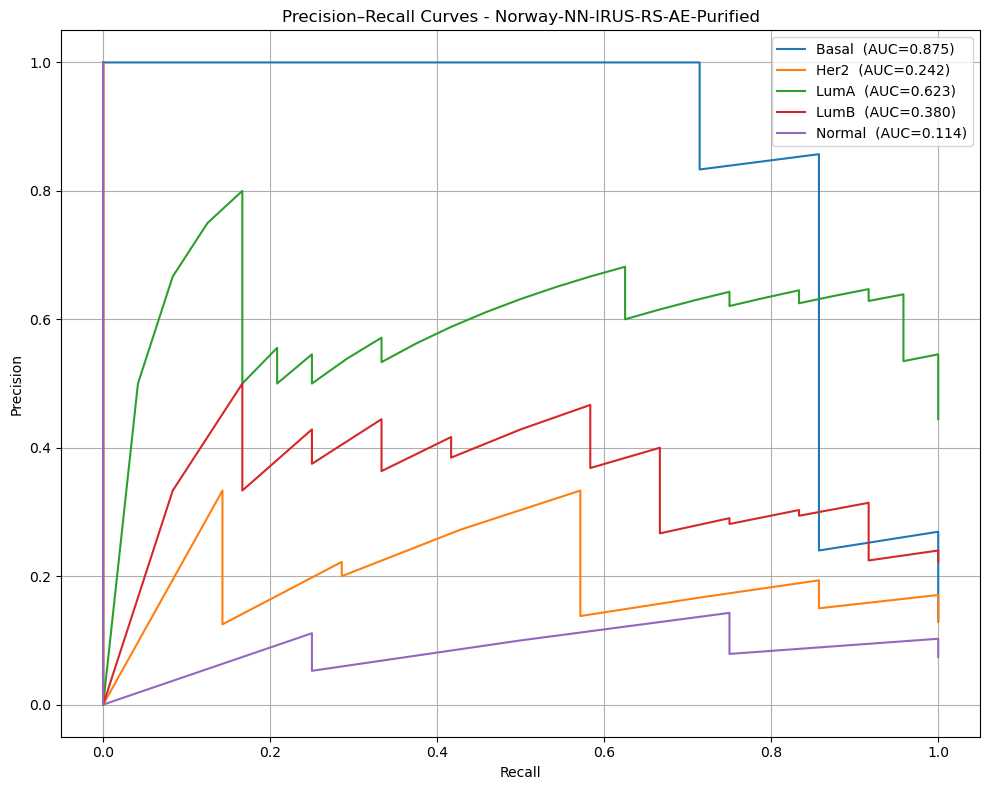

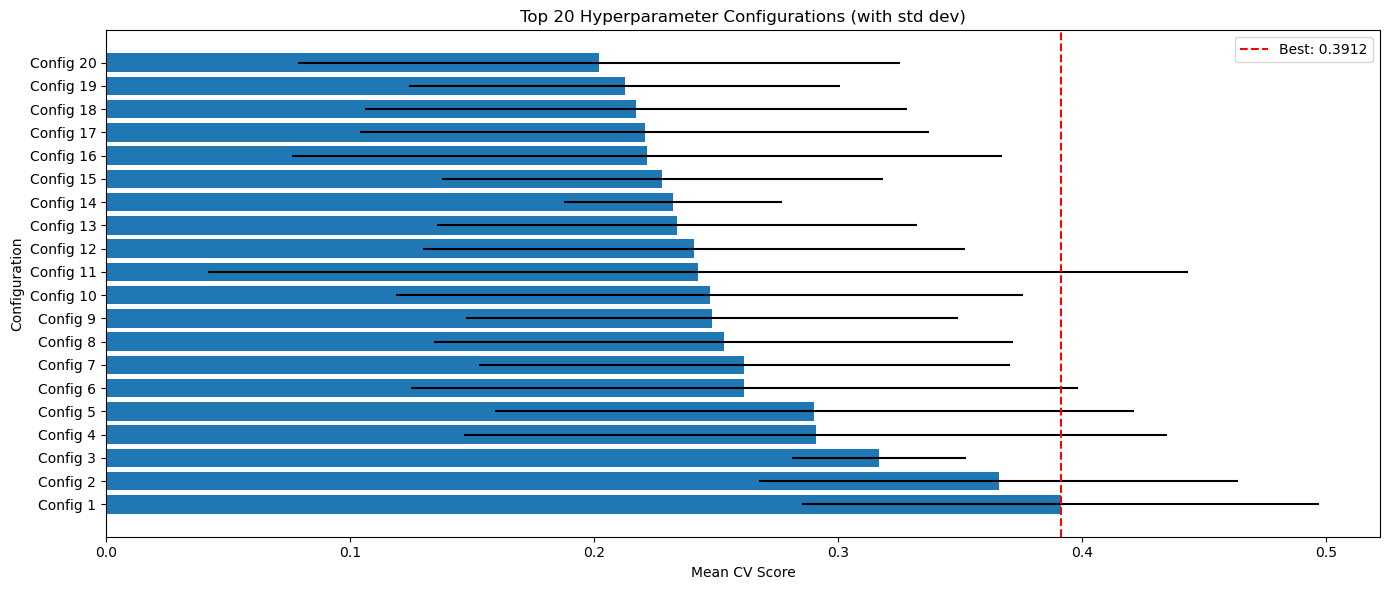


HYPERPARAMETER ANALYSIS:

model__activation:
  leakyrelu: appears 7/10 times in top 10
  relu: appears 2/10 times in top 10
  tanh: appears 1/10 times in top 10

model__learning_rate:
  0.001: appears 4/10 times in top 10
  0.002: appears 3/10 times in top 10
  0.0001: appears 3/10 times in top 10

batch_size:
  16: appears 8/10 times in top 10
  32: appears 2/10 times in top 10

model__dropout_rate1:
  0.3: appears 4/10 times in top 10
  0.1: appears 4/10 times in top 10
  0.2: appears 2/10 times in top 10

model__dropout_rate2:
  0.4: appears 4/10 times in top 10
  0.2: appears 3/10 times in top 10
  0.1: appears 2/10 times in top 10
  0.3: appears 1/10 times in top 10


C:\Users\Alvin\AppData\Local\Temp\ipykernel_1152\3827501799.py:117: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cv_scores, labels=[f'Fold {i+1}' for i in range(n_folds)])


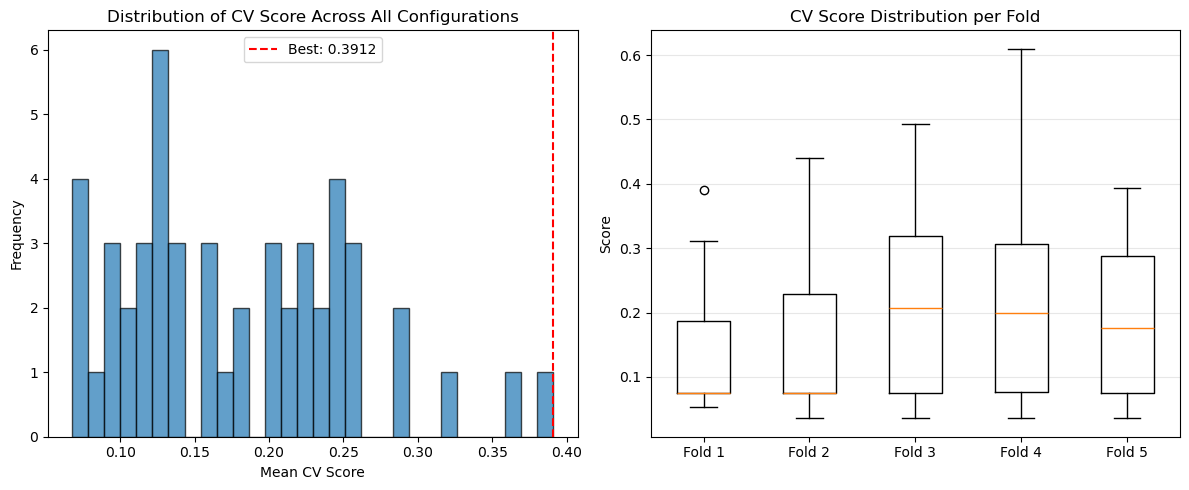


SUMMARY STATISTICS:
Best CV Score: 0.3912
Test Score: 0.3095
Mean CV Score (all configs): 0.1796
Std CV Score (all configs): 0.0782
Min CV Score: 0.0676
Max CV Score: 0.3912


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve,average_precision_score
from sklearn.preprocessing import label_binarize
from collections import Counter
import numpy as np

test_acc = random_search.score(X_test_encoded, y_test_enc)

print(f"\nTest Score (Best Neural Network): {test_acc:.4f}")

# Predict probabilities and classes
y_pred_proba = best_model.predict_proba(X_test_encoded)
y_pred_classes = best_model.predict(X_test_encoded)

# -------------------------------
# CLASSIFICATION REPORT
# -------------------------------
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_classes, target_names=le.classes_))

# -------------------------------
# CONFUSION MATRIX
# -------------------------------
cm = confusion_matrix(y_test_enc, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# -------------------------------
# PRECISION–RECALL CURVES
# -------------------------------
# Binarize true labels
y_test_binarized = label_binarize(y_test_enc, classes=np.arange(len(le.classes_)))

plt.figure(figsize=(10, 8))

for i, class_name in enumerate(le.classes_):
    precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    auc_score = average_precision_score(y_test_binarized[:, i], y_pred_proba[:, i])
    plt.plot(recall, precision, label=f"{class_name}  (AUC={auc_score:.3f})")


plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves - Norway-NN-IRUS-RS-AE-Purified")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
#  Results Visualization
# ------------------------------------------------------------------

results_df = pd.DataFrame(random_search.cv_results_)

# Plot top 20 configurations
plt.figure(figsize=(14, 6))
top_20 = results_df.nsmallest(20, 'rank_test_score')

plt.barh(range(len(top_20)), top_20['mean_test_score'], xerr=top_20['std_test_score'])
plt.yticks(range(len(top_20)), [f"Config {i+1}" for i in range(len(top_20))])
plt.xlabel('Mean CV Score')
plt.ylabel('Configuration')
plt.title('Top 20 Hyperparameter Configurations (with std dev)')
plt.axvline(x=random_search.best_score_, color='r', linestyle='--', label=f'Best: {random_search.best_score_:.4f}')
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# Hyperparameter importance analysis
# ------------------------------------------------------------------

print("\n" + "="*80)
print("HYPERPARAMETER ANALYSIS:")
print("="*80)

top_10_configs = results_df.nsmallest(10, 'rank_test_score')

for param in ['model__activation', 
              'model__learning_rate', 'batch_size', 'model__dropout_rate1', 'model__dropout_rate2']:
    print(f"\n{param}:")
    param_values = [config[param] for config in top_10_configs['params']]
    counts = Counter(param_values)
    for value, count in counts.most_common():
        print(f"  {value}: appears {count}/10 times in top 10")

# ------------------------------------------------------------------
# CV Accuracy Distribution
# ------------------------------------------------------------------

plt.figure(figsize=(12, 5))

# Histogram of all CV Score
plt.subplot(1, 2, 1)
plt.hist(results_df['mean_test_score'], bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=random_search.best_score_, color='r', linestyle='--', 
            label=f'Best: {random_search.best_score_:.4f}')
plt.xlabel('Mean CV Score')
plt.ylabel('Frequency')
plt.title('Distribution of CV Score Across All Configurations')
plt.legend()

# Box plot (adjust to number of folds)
plt.subplot(1, 2, 2)
n_folds = random_search.cv.n_splits  # dynamically use actual folds
cv_scores = [results_df[f'split{i}_test_score'] for i in range(n_folds)]
plt.boxplot(cv_scores, labels=[f'Fold {i+1}' for i in range(n_folds)])
plt.ylabel('Score')
plt.title('CV Score Distribution per Fold')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------------

print("\n" + "="*80)
print("SUMMARY STATISTICS:")
print("="*80)
print(f"Best CV Score: {random_search.best_score_:.4f}")
print(f"Test Score: {test_acc:.4f}")
print(f"Mean CV Score (all configs): {results_df['mean_test_score'].mean():.4f}")
print(f"Std CV Score (all configs): {results_df['mean_test_score'].std():.4f}")
print(f"Min CV Score: {results_df['mean_test_score'].min():.4f}")
print(f"Max CV Score: {results_df['mean_test_score'].max():.4f}")

In [8]:

# If you used a Scikeras wrapper
print("\nBest Keras model parameters:")
print(best_model.get_params())


Best Keras model parameters:
{'model': <function create_classifier at 0x0000013F33AD0FE0>, 'build_fn': None, 'warm_start': False, 'random_state': 0, 'optimizer': 'rmsprop', 'loss': 'sparse_categorical_crossentropy', 'metrics': None, 'batch_size': 16, 'validation_batch_size': None, 'verbose': 0, 'callbacks': [<keras.src.callbacks.early_stopping.EarlyStopping object at 0x0000014205507D90>, <__main__.HistoryLogger object at 0x00000141FF82A390>], 'validation_split': 0.0, 'shuffle': True, 'run_eagerly': False, 'epochs': 100, 'class_weight': None, 'model__learning_rate': 0.002, 'model__hidden_dim': 200, 'model__dropout_rate2': 0.2, 'model__dropout_rate1': 0.3, 'model__activation': 'leakyrelu'}


In [9]:
import shap
import lime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, ReLU
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam

# ==========================================
# SETTINGS
# ==========================================
original_feature_names = X_train.columns.tolist()

MAX_BACKGROUND = 30
MAX_EXPLAIN = 30
SHAP_BATCH_SIZE = 10
RANDOM_STATE = 42
TOP_K = 10

OUT_DIR = "./explain_results_ir"
os.makedirs(OUT_DIR, exist_ok=True)

# ==========================================
# BUILD AUTOENCODER (EXPLICIT DECODER)
# ==========================================
def build_autoencoder2(input_dim, encoding_dim=500, hidden_dim1=5000, hidden_dim2=2000,
                      l2_reg=1e-14, learning_rate=3e-5):
    # Encoder
    inp = Input(shape=(input_dim,))
    x = Dense(hidden_dim1, kernel_regularizer=regularizers.l2(l2_reg))(inp)
    x = ReLU()(x)
    x = Dense(hidden_dim2, kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = ReLU()(x)
    encoded = Dense(encoding_dim, kernel_regularizer=regularizers.l2(l2_reg))(x)
    encoded_act = ReLU()(encoded)

    # Decoder
    x = Dense(hidden_dim2, kernel_regularizer=regularizers.l2(l2_reg))(encoded_act)
    x = ReLU()(x)
    x = Dense(hidden_dim1, kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = ReLU()(x)
    decoded = Dense(input_dim, activation='linear')(x)

    autoencoder2 = Model(inp, decoded)
    encoder2 = Model(inp, encoded_act)

    # Explicit decoder model
    encoded_input = Input(shape=(encoding_dim,))
    d = autoencoder2.layers[-6](encoded_input)  # first decoder Dense
    d = autoencoder2.layers[-5](d)             # first ReLU
    d = autoencoder2.layers[-4](d)             # second decoder Dense
    d = autoencoder2.layers[-3](d)             # second ReLU
    d = autoencoder2.layers[-2](d)             # output Dense
    decoder2 = Model(encoded_input, d)

    autoencoder2.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return autoencoder2, encoder2, decoder2

# Assume input_dim is known
autoencoder2, encoder2, decoder2 = build_autoencoder2(input_dim)

# ==========================================
# MODEL EXTRACTION
# ==========================================
print("\n[MODEL] Extracting best Keras model...")
keras_model = None
try:
    keras_model = getattr(best_model, "model_", None)
    if keras_model is None:
        keras_model = best_model.named_steps.get("nn").model_
except Exception:
    keras_model = best_model  # fallback

if keras_model is None:
    raise ValueError("Could not extract Keras model from best_model!")

print("Using Keras model:", type(keras_model))
print(f"Model input shape: {keras_model.input_shape}")

# ==========================================
# USE ENCODED DATA FOR SHAP
# ==========================================
if isinstance(X_train_encoded, pd.DataFrame):
    X_train_arr = X_train_encoded.values
    X_test_arr = X_test_encoded.values
else:
    X_train_arr = X_train_encoded
    X_test_arr = X_test_encoded

feature_names_encoded = [f"Encoded_{i}" for i in range(X_train_arr.shape[1])]
print(f"Using {len(feature_names_encoded)} encoded features")

# ==========================================
# SHAP EXPLANATIONS
# ==========================================
def shap_sample_fallback(X, n, random_state):
    if hasattr(shap, "sample"):
        return shap.sample(X, n, random_state=random_state)
    else:
        idx = np.random.RandomState(random_state).choice(len(X), size=n, replace=False)
        return X[idx]

small_bg = shap_sample_fallback(X_train_arr, min(MAX_BACKGROUND, len(X_train_arr)), RANDOM_STATE)
small_test = shap_sample_fallback(X_test_arr, min(MAX_EXPLAIN, len(X_test_arr)), RANDOM_STATE)

try:
    print("Attempting DeepExplainer...")
    explainer = shap.DeepExplainer(keras_model, small_bg)
    shap_values = explainer.shap_values(small_test, check_additivity=False)
    expected_value = explainer.expected_value
    use_deep = True
except Exception as e:
    print(f"DeepExplainer failed: {e}")
    print("→ Using KernelExplainer with batch processing...")
    def model_wrapper(X):
        return keras_model.predict(X, batch_size=32, verbose=0)
    explainer = shap.KernelExplainer(model_wrapper, small_bg)
    shap_values_list = []
    total_batches = int(np.ceil(len(small_test) / SHAP_BATCH_SIZE))
    for i in range(0, len(small_test), SHAP_BATCH_SIZE):
        batch_end = min(i + SHAP_BATCH_SIZE, len(small_test))
        batch = small_test[i:batch_end]
        batch_shap = explainer.shap_values(batch)
        shap_values_list.append(batch_shap)
        gc.collect()
    if isinstance(shap_values_list[0], list):
        n_classes = len(shap_values_list[0])
        shap_values = [np.vstack([b[c] for b in shap_values_list]) for c in range(n_classes)]
    else:
        shap_values = np.vstack(shap_values_list)
    expected_value = explainer.expected_value
    use_deep = False

del explainer
gc.collect()

if isinstance(shap_values, list):
    shap_values = np.stack([np.array(s) for s in shap_values], axis=2)

# ==========================================
# OVERALL SHAP IMPORTANCE (ENCODED)
# ==========================================
if shap_values.ndim == 3:
    shap_values_overall = np.abs(shap_values).max(axis=2)
else:
    shap_values_overall = np.abs(shap_values)

mean_abs_shap_overall = shap_values_overall.mean(axis=0)
shap_importances_overall = pd.DataFrame({
    "Feature": feature_names_encoded,
    "MeanAbsSHAP_MaxAcrossClasses": mean_abs_shap_overall
}).sort_values(by="MeanAbsSHAP_MaxAcrossClasses", ascending=False)

top_features_overall = shap_importances_overall.head(TOP_K)
top_features_overall.to_csv(os.path.join(OUT_DIR, "top_features_overall_max.csv"), index=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_features_overall,
            x="MeanAbsSHAP_MaxAcrossClasses",
            y="Feature",
            palette="Greens_d")
plt.title("Top 10 SHAP Encoded Features (Overall)")
plt.xlabel("Mean |SHAP| Value")
plt.ylabel("Encoded Feature")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "top10_overall_bar.png"), dpi=150)
plt.close()

print("\n=== Top 10 Encoded Features (Overall) ===")
print(top_features_overall)

# ==========================================
# DECODE SHAP VALUES TO ORIGINAL SPACE
# ==========================================
def decode_shap_values(shap_values_encoded, autoencoder, encoding_dim, original_dim):
    """
    Approximate decoding of SHAP values from encoded space to original feature space.
    Uses decoder weights to map SHAP values back.
    
    Parameters:
        shap_values_encoded: np.array, SHAP values in encoded space
        autoencoder: trained Keras autoencoder
        encoding_dim: int, size of encoded vector
        original_dim: int, number of original features
    """
    # Build decoder input
    from tensorflow.keras.layers import Input
    from tensorflow.keras.models import Model

    encoded_input = Input(shape=(encoding_dim,))
    
    # Manually get decoder layers (assume your autoencoder is structured like yours)
    # Here we use all layers after the encoded layer
    decoder_layers = autoencoder.layers[-6:]  # adjust according to your autoencoder
    
    x = encoded_input
    for layer in decoder_layers:
        x = layer(x)
    decoder_model = Model(encoded_input, x)

    # Propagate SHAP values through decoder using weights
    decoded_shap = shap_values_encoded.copy()
    for layer in decoder_layers:
        if hasattr(layer, "get_weights") and len(layer.get_weights()) > 0:
            W, b = layer.get_weights()
            decoded_shap = np.dot(decoded_shap, W)
            # Apply ReLU if exists
            if hasattr(layer, "activation") and layer.activation.__name__ == "relu":
                decoded_shap = np.maximum(decoded_shap, 0)
    
    # Truncate/pad to match original feature size
    decoded_shap = decoded_shap[:, :original_dim]
    return decoded_shap


encoding_dim = 500  # match your autoencoder's encoding_dim
original_dim = X_train.shape[1]

# Decode overall SHAP values
decoded_shap_full = decode_shap_values(shap_values_overall, autoencoder2, encoding_dim, original_dim)
decoded_importance = np.mean(np.abs(decoded_shap_full), axis=0)

decoded_df = pd.DataFrame({
    "Feature": original_feature_names,
    "ApproxMeanAbsSHAP": decoded_importance
}).sort_values(by="ApproxMeanAbsSHAP", ascending=False)

decoded_df.to_csv(os.path.join(OUT_DIR, "decoded_shap_features.csv"), index=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=decoded_df.head(TOP_K),
    x="ApproxMeanAbsSHAP",
    y="Feature",
    palette="Blues_d"
)
plt.title("Top 10 Original Features (Decoded SHAP Approximation)")
plt.xlabel("Approx. Mean |SHAP| Value")
plt.ylabel("Original Feature")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "top10_decoded_bar.png"), dpi=150)
plt.close()

# ==========================================
# DECODE SHAP VALUES FOR EACH CLASS
# ==========================================
print("\n[SHAP] Decoding SHAP values to original feature space for each class...")

if shap_values.ndim == 3:
    n_classes = shap_values.shape[2]
    decoded_shap_per_class = []
    
    # Loop through each class and decode separately
    for class_idx in range(n_classes):
        print(f"  Decoding class {class_idx}...")
        class_shap_encoded = shap_values[:, :, class_idx]  # Extract SHAP for this class
        decoded_class_shap = decode_shap_values(class_shap_encoded, autoencoder2, encoding_dim, original_dim)
        decoded_shap_per_class.append(decoded_class_shap)
    
    # Stack back into 3D array: (samples, original_features, classes)
    decoded_shap_3d = np.stack(decoded_shap_per_class, axis=2)
    print(f"  ✓ Decoded SHAP values shape: {decoded_shap_3d.shape}")
else:
    # Single output (binary or regression)
    decoded_shap_3d = decode_shap_values(shap_values, autoencoder2, encoding_dim, original_dim)
    print(f"  ✓ Decoded SHAP values shape: {decoded_shap_3d.shape}")

# ==========================================
# EXTRACT CLASS LABELS FOR SHAP
# ==========================================
try:
    # Use the original LabelEncoder classes
    class_names = le.classes_.tolist()
    print(f"\n[SHAP] Detected class names: {class_names}")
except Exception as e:
    print(f"[SHAP] Could not extract class names: {e}")
    class_names = [f"Class {i}" for i in range(n_classes)]


# ==========================================
# DECODED SHAP SUMMARY PLOTS FOR EACH CLASS
# ==========================================
if decoded_shap_3d.ndim == 3:
    n_classes = decoded_shap_3d.shape[2]
    print(f"\n[SHAP] Creating decoded summary plots for {n_classes} classes...")
    
    # Get original test data for plotting (match the sample size)
    if isinstance(X_test, pd.DataFrame):
        X_test_original = X_test.values[:len(small_test)]
    else:
        X_test_original = X_test[:len(small_test)]
    
    for class_idx in range(n_classes):
        class_label = class_names[class_idx] if class_names else f"Class {class_idx}"
        class_shap_decoded = decoded_shap_3d[:, :, class_idx]
        
        print(f"  Creating plots for {class_label}...")
        
        # Summary plot (beeswarm) - Shows distribution of SHAP values
        plt.figure(figsize=(12, 10))
        shap.summary_plot(
            class_shap_decoded,
            X_test_original,
            feature_names=original_feature_names,
            max_display=TOP_K,
            show=False
        )
        plt.title(f"SHAP Summary Plot (Original Features) - {class_label}", fontsize=14, pad=20)
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, f"shap_summary_decoded_{class_label.lower().replace(' ', '_')}.png"), 
                   dpi=150, bbox_inches='tight')
        plt.close()
        
        # Bar plot (mean absolute SHAP) - Shows feature importance
        plt.figure(figsize=(10, 8))
        shap.summary_plot(
            class_shap_decoded,
            X_test_original,
            feature_names=original_feature_names,
            max_display=TOP_K,
            plot_type="bar",
            show=False
        )
        plt.title(f"SHAP Feature Importance (Original Features) - {class_label}", fontsize=14, pad=20)
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, f"shap_bar_decoded_{class_label.lower().replace(' ', '_')}.png"), 
                   dpi=150, bbox_inches='tight')
        plt.close()
        
        # Save class-specific decoded importance to CSV
        mean_abs_shap_class = np.abs(class_shap_decoded).mean(axis=0)
        class_importance_decoded = pd.DataFrame({
            "Feature": original_feature_names,
            "MeanAbsSHAP_Decoded": mean_abs_shap_class
        }).sort_values(by="MeanAbsSHAP_Decoded", ascending=False)
        class_importance_decoded.to_csv(
            os.path.join(OUT_DIR, f"top_features_decoded_{class_label.lower().replace(' ', '_')}.csv"), 
            index=False
        )
        
        print(f"  ✓ {class_label} decoded summary plots saved")
    
    print(f"\n✓ Decoded summary plots for all {n_classes} classes completed")
else:
    # Binary classification or regression
    print("\n[SHAP] Creating decoded summary plot (single output)...")
    
    if isinstance(X_test, pd.DataFrame):
        X_test_original = X_test.values[:len(small_test)]
    else:
        X_test_original = X_test[:len(small_test)]
    
    plt.figure(figsize=(12, 10))
    shap.summary_plot(
        decoded_shap_3d,
        X_test_original,
        feature_names=original_feature_names,
        max_display=TOP_K,
        show=False
    )
    plt.title("SHAP Summary Plot (Original Features)", fontsize=14, pad=20)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "shap_summary_decoded.png"), dpi=150, bbox_inches='tight')
    plt.close()
    
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        decoded_shap_3d,
        X_test_original,
        feature_names=original_feature_names,
        max_display=TOP_K,
        plot_type="bar",
        show=False
    )
    plt.title("SHAP Feature Importance (Original Features)", fontsize=14, pad=20)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "shap_bar_decoded.png"), dpi=150, bbox_inches='tight')
    plt.close()
    
    print("  ✓ Decoded summary plots saved")

print("\n✅ SHAP analysis complete!")
print(f"📁 Results saved to: {OUT_DIR}")
print("📊 Generated files:")
print("   - Encoded feature importance (overall)")
print("   - Decoded feature importance (overall)")
print("   - Per-class decoded summary plots (beeswarm + bar)")
print("   - Per-class decoded feature importance CSVs")
print("\n⚠️  Note: Decoded SHAP values are approximate due to nonlinear decoder layers.")


[MODEL] Extracting best Keras model...
Using Keras model: <class 'keras.src.models.functional.Functional'>
Model input shape: (None, 500)
Using 500 encoded features
Attempting DeepExplainer...


c:\Users\Alvin\anaconda3\Lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
c:\Users\Alvin\anaconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_1912
Received: inputs=['Tensor(shape=(30, 500))']
  warnings.warn(msg)
c:\Users\Alvin\anaconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_1912
Received: inputs=['Tensor(shape=(60, 500))']
  warnings.warn(msg)


DeepExplainer failed: in user code:

    File "c:\Users\Alvin\anaconda3\Lib\site-packages\shap\explainers\_deep\deep_tf.py", line 265, in grad_graph  *
        x_grad = tape.gradient(out, shap_rAnD)

    LookupError: gradient registry has no entry for: shap_LeakyRelu

→ Using KernelExplainer with batch processing...


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

...

C:\Users\Alvin\AppData\Local\Temp\ipykernel_1152\1003498350.py:321: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
C:\Users\Alvin\AppData\Local\Temp\ipykernel_1152\1003498350.py:306: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


  ✓ LumA decoded summary plots saved
  Creating plots for LumB...


C:\Users\Alvin\AppData\Local\Temp\ipykernel_1152\1003498350.py:321: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
C:\Users\Alvin\AppData\Local\Temp\ipykernel_1152\1003498350.py:306: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


  ✓ LumB decoded summary plots saved
  Creating plots for Normal...
  ✓ Normal decoded summary plots saved

✓ Decoded summary plots for all 5 classes completed

✅ SHAP analysis complete!
📁 Results saved to: ./explain_results_ir
📊 Generated files:
   - Encoded feature importance (overall)
   - Decoded feature importance (overall)
   - Per-class decoded summary plots (beeswarm + bar)
   - Per-class decoded feature importance CSVs

⚠️  Note: Decoded SHAP values are approximate due to nonlinear decoder layers.


C:\Users\Alvin\AppData\Local\Temp\ipykernel_1152\1003498350.py:321: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
